In [30]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
def weekday_word(weekday):
    if weekday==0:
        return "Monday"
    elif weekday==1:
        return "Tuesday"
    elif weekday==2:
        return "Wednesday"
    elif weekday==3:
        return "Thursday"
    elif weekday==4:
        return "Friday"
    elif weekday==5:
        return "Saturday"
    else:
        return "Sunday"
    
def is_weekend(weekday):
    return weekday in [5,6]

### Feature forklaring
- User Type: 
    - Customer = 24-hour pass or 3-day pass
    - Subscriber = Annual Member
- Gender:
    - 0 -> Unknown
    - 1 -> Male
    - 2 -> Female

In [ ]:
f=pd.read_csv(r"")

In [33]:
f.describe()

,Unnamed: 0,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender
count,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07
mean,8.774169e+06,9.887432e+02,1.589282e+03,4.073737e+01,-7.398260e+01,1.580830e+03,4.073704e+01,-7.398281e+01,2.656141e+04,1.978993e+03,1.148613e+00
std,5.065769e+06,1.889584e+04,1.439432e+03,3.225813e-02,1.912753e-02,1.438502e+03,3.206583e-02,1.919611e-02,6.222916e+03,1.192922e+01,5.438043e-01
min,0.000000e+00,6.100000e+01,7.200000e+01,4.064654e+01,-7.402535e+01,7.200000e+01,4.064654e+01,-7.408364e+01,1.452900e+04,1.885000e+03,0.000000e+00
25%,4.387084e+06,3.580000e+02,3.800000e+02,4.071755e+01,-7.399521e+01,3.800000e+02,4.071755e+01,-7.399595e+01,2.029300e+04,1.969000e+03,1.000000e+00
50%,8.774169e+06,6.050000e+02,5.050000e+02,4.073818e+01,-7.398565e+01,5.050000e+02,4.073756e+01,-7.398602e+01,2.827000e+04,1.981000e+03,1.000000e+00
75%,1.316125e+07,1.060000e+03,3.249000e+03,4.075763e+01,-7.397283e+01,3.249000e+03,4.075725e+01,-7.397344e+01,3.185200e+04,1.989000e+03,1.000000e+00
max,1.754834e+07,1.951005e+07,3.721000e+03,4.550636e+01,-7.356891e+01,3.721000e+03,4.550636e+01,-7.356891e+01,3.583100e+04,2.002000e+03,2.000000e+00


In [34]:
f = f.rename({"Unnamed: 0": "Trip ID"}, axis="columns")
f = f.set_index("Trip ID")

In [35]:
f.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
Trip ID,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.4340,2018-01-01 14:07:08.1860,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,723,2018-01-01 15:33:30.1820,2018-01-01 15:45:33.3410,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,496,2018-01-01 15:39:18.3370,2018-01-01 15:47:35.1720,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,306,2018-01-01 15:40:13.3720,2018-01-01 15:45:20.1910,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,306,2018-01-01 18:14:51.5680,2018-01-01 18:19:57.6420,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [36]:
f['starttime'] = pd.to_datetime(f['starttime'], format='%Y-%m-%d %H:%M:%S.%f')
f['stoptime'] = pd.to_datetime(f['stoptime'], format='%Y-%m-%d %H:%M:%S.%f')
f['weekday']= f['starttime'].dt.weekday
f['is_weekend']=[is_weekend(el) for el in f['weekday']]
# sm_dummies=pd.get_dummies(f, columns=['usertype'])
# sm_dummies.head()

In [37]:
f.dtypes

tripduration                        int64
starttime                  datetime64[ns]
stoptime                   datetime64[ns]
start_station_id                  float64
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_latitude              float64
end_station_longitude             float64
bikeid                              int64
usertype                           object
birth_year                          int64
gender                              int64
weekday                             int64
is_weekend                           bool
dtype: object

In [38]:
# sm_dummies.dtypes

# Looking at coordinates

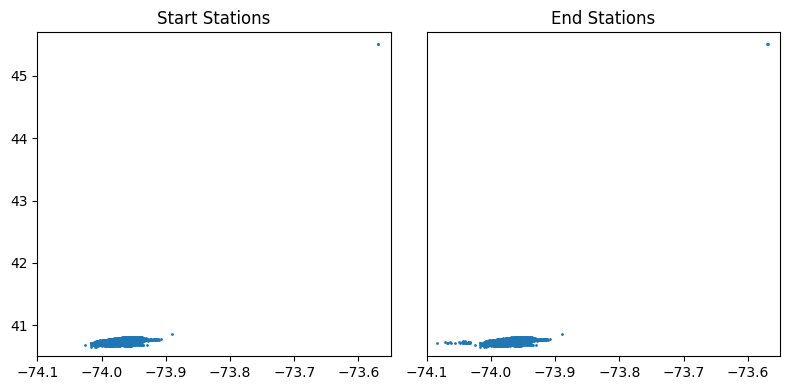

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.55), (40.5, 45.7)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# Remove outlier

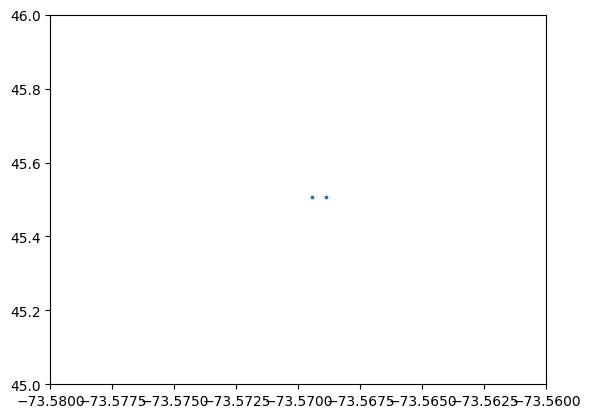

In [40]:
plt.scatter(start_station_df['longitude'], start_station_df['latitude'], s=3)
plt.xlim((-73.58, -73.56))
plt.ylim((45, 46))
plt.show()

In [41]:
start_station_df[start_station_df.longitude > -73.6]

,latitude,longitude
start_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [42]:
end_station_df[end_station_df.longitude > -73.6]

,latitude,longitude
end_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [43]:
f[
    (f.start_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [44]:
f[
    (f.end_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,
8772457,1634200,2018-07-18 18:27:51.511,2018-08-06 16:24:32.388,3036.0,40.662908,-73.999722,3488.0,45.506364,-73.569463,24354,Subscriber,1988,1,2,False


In [45]:
f[
    (f.start_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [46]:
f[
    (f.end_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [47]:
f[
    (f.start_station_id == 3488) | (f.end_station_id == 3488) |
    (f.start_station_id == 3650) | (f.end_station_id == 3650)
].describe()

,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender,weekday
count,8.200000e+01,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2.954804e+04,3636.585366,45.447203,-73.574180,3642.097561,45.506269,-73.568933,23651.158537,1985.792683,1.012195,1.378049
std,1.827257e+05,73.784128,0.534860,0.047574,35.110974,0.000022,0.000121,1256.116408,2.752049,0.248149,1.329998
min,6.200000e+01,3036.000000,40.662908,-73.999722,3488.000000,45.506264,-73.569463,17667.000000,1969.000000,0.000000,0.000000
25%,2.235000e+02,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,21928.000000,1986.000000,1.000000,0.000000
50%,9.390000e+02,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,1.000000
75%,2.653500e+03,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,3.000000
max,1.634200e+06,3650.000000,45.506364,-73.568906,3650.000000,45.506364,-73.568906,24354.000000,1988.000000,2.000000,4.000000


We have two outliers stations with id 3448 and 3650. We found that they are both placed right next to one another in Montreal, Canada. From the above cells, it is apparent that all but one trips completed with start or end point in Montreal (station 3488 and 3650) are trips in Montreal only.

There is a single trip from Brooklyn (station 3036) to Montreal (station 3488). It's duration is 18.9 days and out of 17 million trips completed, this one is the only one travelling to Montreal. Therefore we classify stations in Montreal as not relevant and outliers.

In [48]:
f = f.drop(
    f[
        (f.start_station_id == 3488) | (f.end_station_id == 3488) |
        (f.start_station_id == 3650) | (f.end_station_id == 3650)
    ].index
)

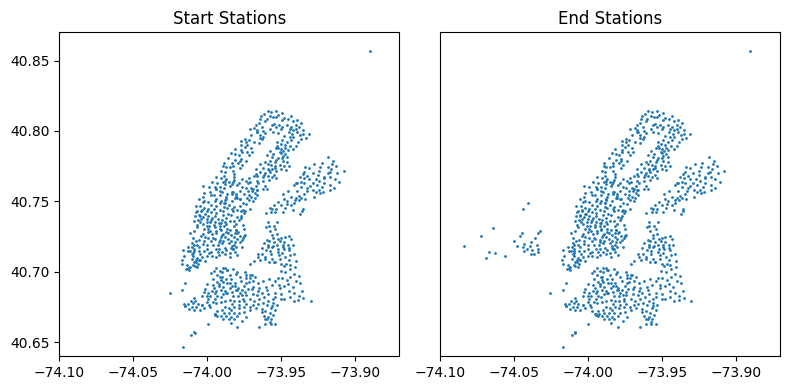

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.87), (40.64, 40.87)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Classifying the stations with ID: NaN

We find that a great deal of stations have ID = NaN. So we try and plot them to find their location.

In [50]:
start_ids = np.unique(f.start_station_id)
end_ids = np.unique(f.end_station_id)
print(f"Number of NaN values in start_station_id: {f.start_station_id.isna().sum()}")
print(f"Number of NaN values in end_station_id: {f.end_station_id.isna().sum()}")
start_station_df[start_station_df.index.isna()]

Number of NaN values in start_station_id: 2497
Number of NaN values in end_station_id: 2497


,latitude,longitude
start_station_id,,
NaN,40.857,-73.89


2497 trips have a station ID with NaN-value

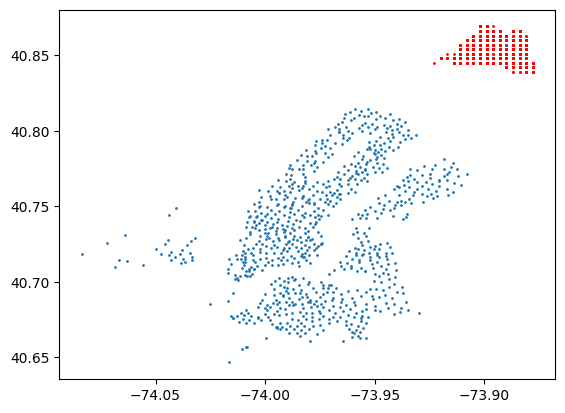

In [51]:
f_nan = f[f.start_station_id.isna()][['start_station_longitude', 'start_station_latitude']]
plt.scatter(f_nan.start_station_longitude, f_nan.start_station_latitude, s=1, c='r', label="NaN-station")
plt.scatter(end_station_df['longitude'], end_station_df['latitude'], s=1)
plt.show()

In [52]:
print("\nCheck: Are the placements different? If all 0, then all placements same")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude) - np.unique(f[f.start_station_id.isna()].end_station_longitude))
print(np.unique(f[f.end_station_id.isna()].start_station_longitude) - np.unique(f[f.end_station_id.isna()].end_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude) - np.unique(f[f.start_station_id.isna()].end_station_latitude))
print(np.unique(f[f.end_station_id.isna()].start_station_latitude) - np.unique(f[f.end_station_id.isna()].end_station_latitude))

print("\nValues for longitude and latitude")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude))

print(f"\nNumber of stations with NaN-value as ID: {len(np.unique(f[f.start_station_id.isna()].start_station_longitude))}")


Check: Are the placements different? If all 0, then all placements same
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Values for longitude and latitude
[-73.923 -73.92  -73.917 -73.914 -73.911 -73.908 -73.905 -73.902 -73.899
 -73.896 -73.893 -73.89  -73.887 -73.884 -73.881 -73.878]
[40.839 40.842 40.845 40.848 40.851 40.854 40.857 40.86  40.863 40.866
 40.869]

Number of stations with NaN-value as ID: 16


Okay, all 16 NaN-ID-stations are located in a single 'cluster' or grouping.
Looking at the placement in a map, the red grouping lies in the Bronx area North of New York. Also as a result of our plotting the single blue dot is the result of dropping duplicates on the ID's. This means that it, in previous plots, represented all the red dots, we now found.

We check whether or not we have data on any trips leaving this grouping. 

In [53]:
f[(f.start_station_id.isna()) & (f.end_station_id.notna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [54]:
f[(f.start_station_id.notna()) & (f.end_station_id.isna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


Okay, no trips from a NaN-ID-station leaves the grouping in the Bronx area. Hence, they have no implication on clusters in the central New York area. Since that is the case they wont be important for rebalancing the bike locations, so we classicy them as outliers

In [55]:
f = f.dropna()

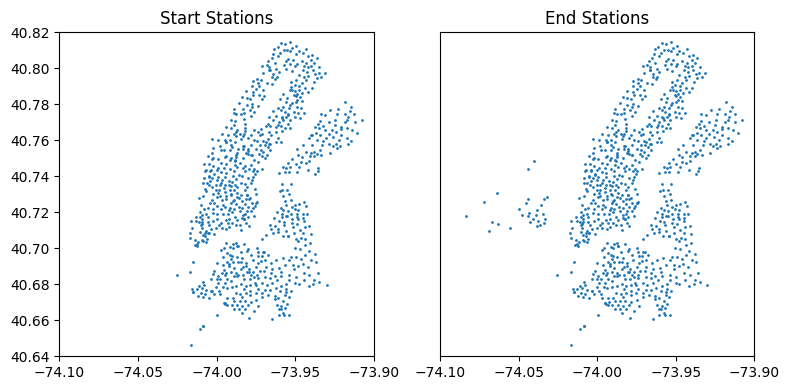

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.9), (40.64, 40.82)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

## K-means

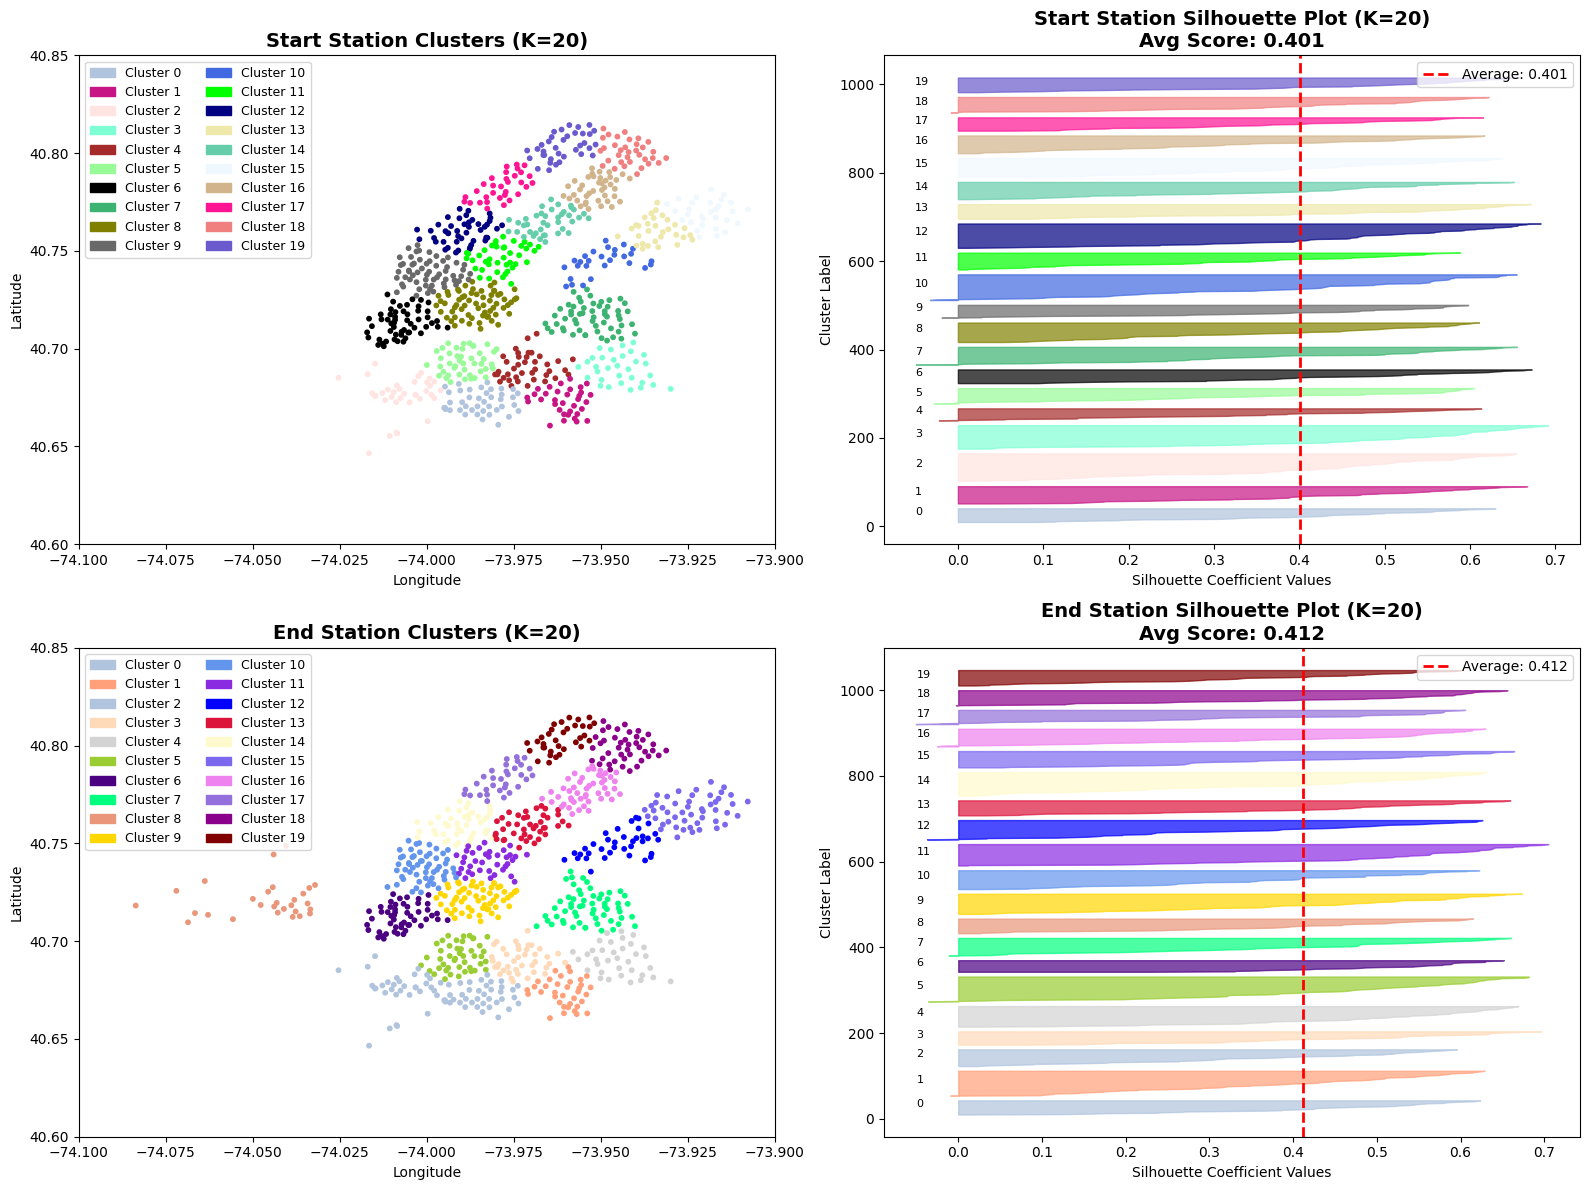

Start Station Average Silhouette Score: 0.401
End Station Average Silhouette Score: 0.412


In [57]:
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import random

K=20

# Fit K-means for start stations
k_start=KMeans(K, random_state=42, n_init=30)
k_end=KMeans(K, random_state=42, n_init=30)

k_start.fit(start_station_df)
k_end.fit(end_station_df)
centroids_start = k_start.cluster_centers_
centroids_end = k_end.cluster_centers_

# Fixing labelling start
order = np.argsort(centroids_start[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_start = np.array([mapping[label] for label in k_start.labels_])

# Fixing labelling end
order = np.argsort(centroids_end[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_end = np.array([mapping[label] for label in k_end.labels_])

dt_clusters_start=start_station_df.copy()
dt_clusters_start['cluster']= fix_labels_start

dt_clusters_end=end_station_df.copy()
dt_clusters_end['cluster']=fix_labels_end

# Generate colors
num_colors=K
colors=list(mcolors.CSS4_COLORS.keys())
cluster_colors_start = random.choices(colors,k=K)
cluster_colors_end = random.choices(colors,k=K)

# Prepare data for start stations
x_points_start=dt_clusters_start["longitude"]
y_points_start=dt_clusters_start["latitude"]
labels_start = dt_clusters_start["cluster"]
x_start=[]
y_start=[]
c_start=[]
for label, x, y in zip(labels_start, x_points_start, y_points_start):
    if label == -1:
        continue
    x_start.append(x)
    y_start.append(y)
    c_start.append(cluster_colors_start[label])

# Prepare data for end stations
x_points_end=dt_clusters_end["longitude"]
y_points_end=dt_clusters_end["latitude"]
labels_end = dt_clusters_end["cluster"]
x_end=[]
y_end=[]
c_end=[]
for label, x, y in zip(labels_end, x_points_end, y_points_end):
    if label==-1:
        continue
    x_end.append(x)
    y_end.append(y)
    c_end.append(cluster_colors_end[label])

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg_start = silhouette_score(start_station_df, k_start.labels_)
sample_silhouette_values_start = silhouette_samples(start_station_df, k_start.labels_)

silhouette_avg_end = silhouette_score(end_station_df, k_end.labels_)
sample_silhouette_values_end = silhouette_samples(end_station_df, k_end.labels_)

# Create combined plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Start Station Clusters
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Plot 2: Start Station Silhouette Plot
ax2 = axes[0, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_start[k_start.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_start[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax2.set_title(f"Start Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_start:.3f}", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient Values")
ax2.set_ylabel("Cluster Label")
ax2.axvline(x=silhouette_avg_start, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_start:.3f}")
ax2.legend()

# Plot 3: End Station Clusters
ax3 = axes[1, 0]
ax3.scatter(x_end, y_end, s=10, c=c_end)
ax3.set_xlim(-74.1, -73.9)
ax3.set_ylim(40.6, 40.85)
ax3.set_title(f'End Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
legend_patches_end = [Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in range(K)]
ax3.legend(handles=legend_patches_end, loc='upper left', fontsize=9, ncol=2)

# Plot 4: End Station Silhouette Plot
ax4 = axes[1, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_end[k_end.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_end[i]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax4.set_title(f"End Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_end:.3f}", 
              fontsize=14, fontweight='bold')
ax4.set_xlabel("Silhouette Coefficient Values")
ax4.set_ylabel("Cluster Label")
ax4.axvline(x=silhouette_avg_end, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_end:.3f}")
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Start Station Average Silhouette Score: {silhouette_avg_start:.3f}")
print(f"End Station Average Silhouette Score: {silhouette_avg_end:.3f}")

# Load a fixed labelling from file

In [58]:
#np.savetxt('fix_labels_start.txt', fix_labels_start) # for updating the fixed cluster labelling used


fixed_cluster_labels = np.loadtxt('fix_labels_start.txt')
dt_clusters_all = dt_clusters_start.copy() # All stations are represented in end_station_id column
dt_clusters_all['cluster'] = fixed_cluster_labels

# Connect clusters with the 17 mio data frame

In [59]:
df_merged_start = f.merge(
    dt_clusters_all['cluster'], 
    left_on='start_station_id', 
    right_index=True, 
    how='left'
)
# df_merged_start = df_merged_start.drop(columns=['Unnamed: 0'])

df_merged_end = f.merge(
    dt_clusters_all['cluster'], 
    left_on='end_station_id', 
    right_index=True, 
    how='left'
)

In [60]:
np.unique(dt_clusters_all[dt_clusters_all.cluster == 12].index)

array([  72.,  173.,  267.,  362.,  379.,  422.,  423.,  447.,  448.,
        449.,  450.,  457.,  465.,  468.,  469.,  477.,  478.,  479.,
        480.,  490.,  492.,  493.,  495.,  499.,  500.,  508.,  513.,
        514.,  515.,  523.,  524.,  525.,  529.,  530.,  533., 2021.,
       3236., 3240., 3255., 3443., 3458., 3466., 3635., 3699., 3712.])

# Investigating a cluster

In [61]:
cluster_12_departures = df_merged_start[df_merged_start["cluster"] == 12].copy()
cluster_12_arrivals = df_merged_end[df_merged_end['cluster'] == 12].copy()
cluster_12_departures.size, cluster_12_arrivals.size

(32407136, 32485504)

In [62]:
cluster_12_departures.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster
Trip ID,,,,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1,0,False,12.0
1,723,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1,0,False,12.0
2,496,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1,0,False,12.0
3,306,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1,0,False,12.0
4,306,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1,0,False,12.0


# Data visualization for a cluster

In [63]:
# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour


# Do the same for arrivals
cluster_12_arrivals['stoptime'] = pd.to_datetime(cluster_12_arrivals['stoptime'])

# Extract date and hour
cluster_12_arrivals['date'] = cluster_12_arrivals['stoptime'].dt.date
cluster_12_arrivals['hour'] = cluster_12_arrivals['stoptime'].dt.hour



In [64]:
grouped_arrivals = (
    cluster_12_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)

all_dates = np.unique(grouped_arrivals.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)


grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)

grouped_departures = (
    cluster_12_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,14,False,Subscriber,1,914.642857,1978.071429
2018-01-01 01:00:00,15,False,Subscriber,1,731.600000,1980.266667
2018-01-01 02:00:00,7,False,Subscriber,1,473.142857,1973.857143
2018-01-01 03:00:00,8,False,Subscriber,1,673.125000,1976.000000
2018-01-01 04:00:00,6,False,Subscriber,1,602.666667,1980.166667
...,...,...,...,...,...,...
2019-01-01 19:00:00,0,0,0,0,0.000000,0.000000
2019-01-01 20:00:00,0,0,0,0,0.000000,0.000000
2019-01-01 21:00:00,0,0,0,0,0.000000,0.000000


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

def plotprediction(series, pred_series, labels=["original", "predicted"], x_axis=None, plot_intervals=False, scale=1.96, plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(15,5))
    plt.title(title)
    if x_axis is None:
        x_axis=series.index
    
    plt.plot(x_axis, pred_series, "r", label=labels[1])
    plt.plot(x_axis, series, "b", label=labels[0])
    

    # Plot confidence intervals for smoothed values

    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

# Training SARIMA model for departures on all training data. 

In [104]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ps = 1
qs = 2
Ps = 1
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_departures = grouped_departures.index < val_start
val_mask_departures   = (grouped_departures.index >= val_start) & (grouped_departures.index < test_start)
test_mask_departures  = (grouped_departures.index >= test_start)& (grouped_departures.index < test_stop)

train_departures = grouped_departures[train_mask_departures].iloc[:, 0]
val_departures   = grouped_departures[val_mask_departures].iloc[:, 0]
test_departures  = grouped_departures[test_mask_departures].iloc[:, 0]

train_mask_all_departures = grouped_departures.index < test_start


train_all_departures = grouped_departures[train_mask_all_departures].iloc[:, 0]

model_sar_depar = SARIMAX(
            train_all_departures,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_depar = model_sar_depar.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )

test_forecast_departures = fit_sar_depar.forecast(steps=len(test_departures))



c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


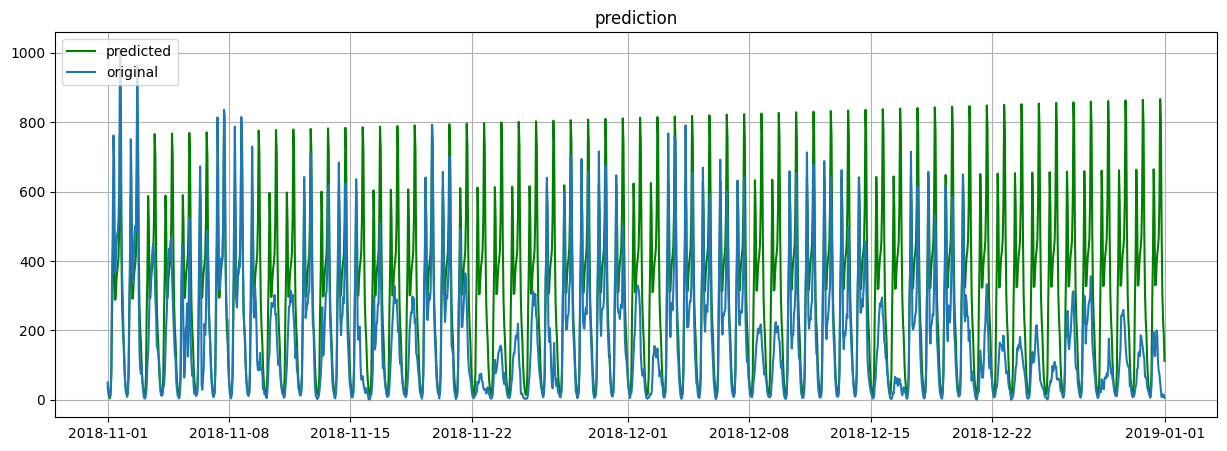

In [ ]:
plotprediction(test_departures,test_forecast_departures, labels=["Observed", "Sarima Prediction"], 
               title = "Test set Predictions - Departures - Sarima model for cluster 12, (p =1, q = 2 , P= 1, Q = 1 ")

In [106]:
mse_test = np.mean((test_departures.values-test_forecast_departures.values)**2)
mse_test

47820.71347296332

In [107]:
print_stats(test_departures,test_forecast_departures, "SARIMA for Departures")

SARIMA for Departures: 
	r^2=-0.479089
	MAE=148.579198
	MAPE=inf


# Training SARIMA model for arrivals on all training data. 

In [108]:
ps = 0
qs = 2
Ps = 2
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_arrivals = grouped_arrivals.index < val_start
val_mask_arrivals   = (grouped_arrivals.index >= val_start) & (grouped_arrivals.index < test_start)
test_mask_arrivals  = (grouped_arrivals.index >= test_start)& (grouped_arrivals.index < test_stop)

train_arrivals = grouped_arrivals[train_mask_arrivals].iloc[:, 0]
val_arrivals   = grouped_arrivals[val_mask_arrivals].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask_arrivals].iloc[:, 0]

train_mask_all_arrivals = grouped_arrivals.index < test_start


train_all_arrivals = grouped_arrivals[train_mask_all_arrivals].iloc[:, 0]

model_sar_arr = SARIMAX(
            train_all_arrivals,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_arr = model_sar_arr.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )

test_forecast_arrivals = fit_sar_arr.forecast(steps=len(test_arrivals))

c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


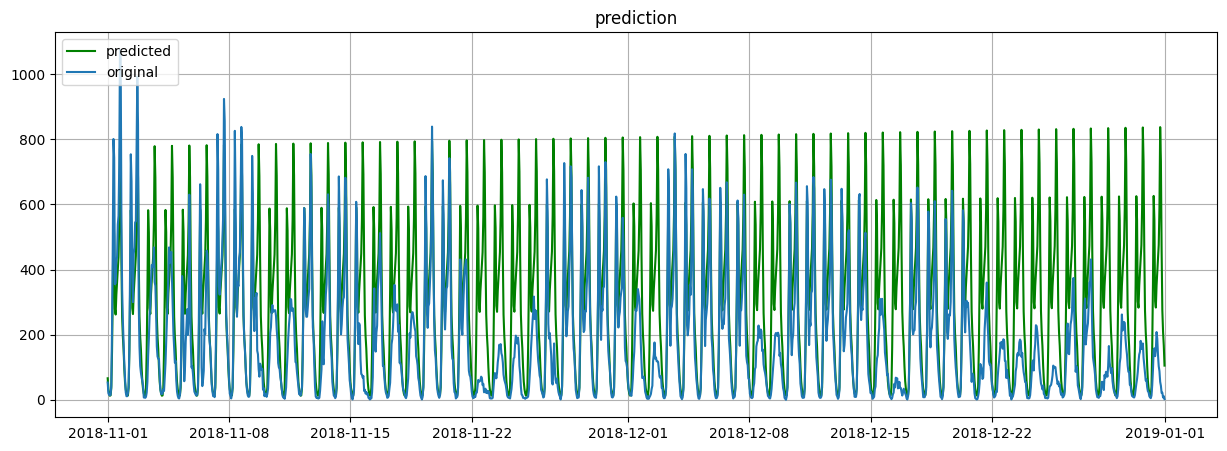

In [109]:
plotprediction(test_arrivals,test_forecast_arrivals)

In [110]:
mse_test = np.mean((test_arrivals.values-test_forecast_arrivals.values)**2)
mse_test

41637.77909531518

In [111]:
print_stats(test_arrivals,test_forecast_arrivals, "SARIMA for Arrivals")

SARIMA for Arrivals: 
	r^2=-0.182057
	MAE=133.068575
	MAPE=inf


# Bike deficit and shifting of bikes

In [121]:
SARIMA_bike_alloc_pred = (test_forecast_arrivals - test_forecast_departures).to_frame(name="diff")
SARIMA_bike_alloc_pred["daily_cumsum"] = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date)["diff"].cumsum()
SARIMA_bike_alloc_pred

,diff,daily_cumsum
2018-11-01 00:00:00,28.685288,28.685288
2018-11-01 01:00:00,12.554634,41.239922
2018-11-01 02:00:00,11.368063,52.607984
2018-11-01 03:00:00,8.328528,60.936512
2018-11-01 04:00:00,0.824468,61.760980
...,...,...
2018-12-31 19:00:00,-26.460015,-534.408475
2018-12-31 20:00:00,-32.724922,-567.133397
2018-12-31 21:00:00,-23.759369,-590.892766
2018-12-31 22:00:00,-20.564807,-611.457573


In [122]:
min_daily_cumsum_pred = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min"),
)
min_daily_cumsum_pred

,min_daily_cumsum
2018-11-01,-167.787397
2018-11-02,-227.479569
2018-11-03,-232.839423
2018-11-04,-235.882001
2018-11-05,-239.021469
...,...
2018-12-27,-587.479187
2018-12-28,-595.301533
2018-12-29,-603.148757
2018-12-30,-611.020920


In [123]:
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)
min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-167.787397,168.0
2018-11-02,-227.479569,228.0
2018-11-03,-232.839423,233.0
2018-11-04,-235.882001,236.0
2018-11-05,-239.021469,240.0
...,...,...
2018-12-27,-587.479187,588.0
2018-12-28,-595.301533,596.0
2018-12-29,-603.148757,604.0
2018-12-30,-611.020920,612.0


In [124]:
SARIMA_bike_alloc_test = (test_arrivals - test_departures).to_frame(name="diff")
SARIMA_bike_alloc_test["daily_cumsum"] = SARIMA_bike_alloc_test.groupby(SARIMA_bike_alloc_test.index.date)["diff"].cumsum()
min_daily_cumsum_test = SARIMA_bike_alloc_test.groupby(SARIMA_bike_alloc_test.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min"),
)
min_daily_cumsum_test

,min_daily_cumsum
2018-11-01,-212
2018-11-02,-235
2018-11-03,-186
2018-11-04,-198
2018-11-05,-298
...,...
2018-12-27,-248
2018-12-28,-40
2018-12-29,-198
2018-12-30,-72


In [126]:
min_daily_cumsum_test["bikes_to_allocate"] = (
    min_daily_cumsum_test["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)
min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-212,212
2018-11-02,-235,235
2018-11-03,-186,186
2018-11-04,-198,198
2018-11-05,-298,298
...,...,...
2018-12-27,-248,248
2018-12-28,-40,40
2018-12-29,-198,198
2018-12-30,-72,72


In [127]:
print_stats(min_daily_cumsum_test["bikes_to_allocate"],min_daily_cumsum_pred["bikes_to_allocate"], "SARIMA bike allocation")

SARIMA bike allocation: 
	r^2=-5.836910
	MAE=202.245902
	MAPE=260.925616


In [128]:
np.mean((min_daily_cumsum_test["bikes_to_allocate"]-min_daily_cumsum_pred["bikes_to_allocate"])**2)

65500.27868852459

In [129]:
np.sqrt(65298)

255.5347334512473